In [1]:
!pip install geopandas -q

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load datacenters dataset
data_centers_df_first = pd.read_csv('data_centers_cleaned.csv')

# Load electricity price dataset
electricity_price_df = pd.read_csv('electricity_price_cleaned.csv')

# Preview the data
print("First dataset:")
display(data_centers_df_first.head())

print("Second dataset:")
display(electricity_price_df.head())

First dataset:


,id,state,state_abb,county,county_id,lat,lon,type,sqft
0,2744301,New Jersey,NJ,Middlesex County,23,40.544256,-74.496521,building,105786.0
1,9474864,North Carolina,NC,Caldwell County,27,35.894738,-81.546515,campus,3407194.0
2,13924557,Iowa,IA,Polk County,153,41.515967,-93.711830,campus,11169421.0
3,14593270,North Carolina,NC,Catawba County,35,35.588771,-81.261809,campus,5431080.0
4,14930068,New Mexico,NM,Bernalillo County,1,35.049942,-106.542822,building,158463.0


Second dataset:


,state,electricity_price
0,Connecticut,19.13
1,Maine,17.15
2,Massachusetts,20.04
3,New Hampshire,18.60
4,Rhode Island,23.90


In [4]:
# Add electricity price to datacenters dataset based on state
data_centers_df = data_centers_df_first.merge(
    electricity_price_df[['state', 'electricity_price']],
    on='state',                       
    how='left'
)

display(data_centers_df.head())

,id,state,state_abb,county,county_id,lat,lon,type,sqft,electricity_price
0,2744301,New Jersey,NJ,Middlesex County,23,40.544256,-74.496521,building,105786.0,13.95
1,9474864,North Carolina,NC,Caldwell County,27,35.894738,-81.546515,campus,3407194.0,7.91
2,13924557,Iowa,IA,Polk County,153,41.515967,-93.711830,campus,11169421.0,6.40
3,14593270,North Carolina,NC,Catawba County,35,35.588771,-81.261809,campus,5431080.0,7.91
4,14930068,New Mexico,NM,Bernalillo County,1,35.049942,-106.542822,building,158463.0,5.13


In [5]:
# Create geometry column from lat/lon
geometry = [Point(xy) for xy in zip(data_centers_df['lon'], data_centers_df['lat'])]

gdf_data_centers = gpd.GeoDataFrame(data_centers_df, geometry=geometry)

# Set coordinate reference system (WGS84)
gdf_data_centers.set_crs(epsg=4326, inplace=True);

In [6]:
# Get USA map data
url_states = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
states = gpd.read_file(url_states)

# Keep only U.S. states
usa = states[states['admin'] == 'United States of America']

<Axes: >

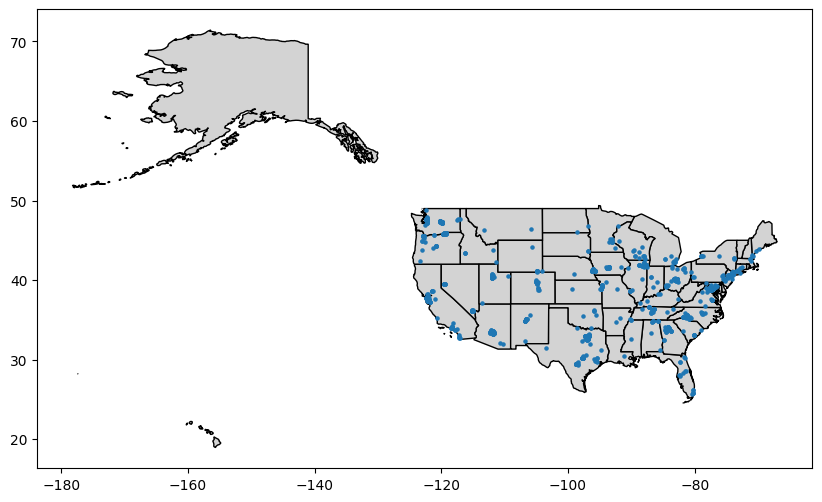

In [7]:
# Plot dataset on USA map
ax = usa.plot(figsize=(10, 6), color='lightgray', edgecolor='black')
gdf_data_centers.plot(ax=ax, markersize=5)

In [8]:
# Check whether  there are datacenters in Hawaii and Alaska
count = (gdf_data_centers['state'] == 'Hawaii').sum()
print(f"Number of data centers in Hawaii: {count}")

count = (gdf_data_centers['state'] == 'Alaska').sum()
print(f"Number of data centers in Alaska: {count}")

Number of data centers in Hawaii: 0
Number of data centers in Alaska: 0


<Axes: >

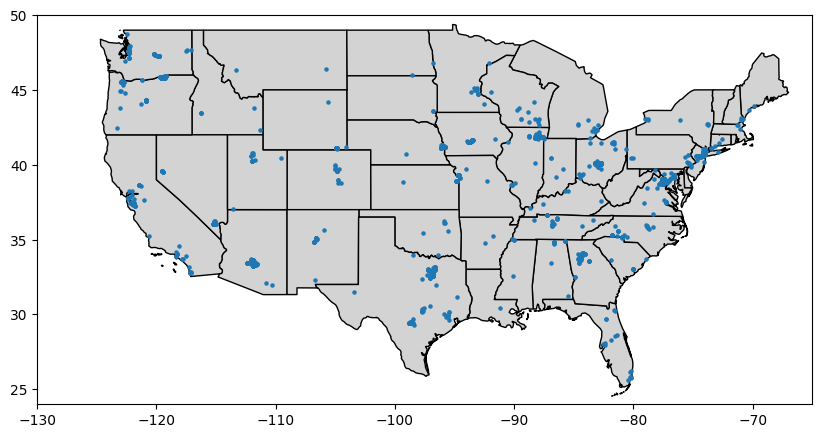

In [9]:
# Plot dataset on USA map without Alaska and Hawaii

ax = usa.plot(figsize=(10, 6), color='lightgray', edgecolor='black')
ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)
gdf_data_centers.plot(ax=ax, markersize=5)

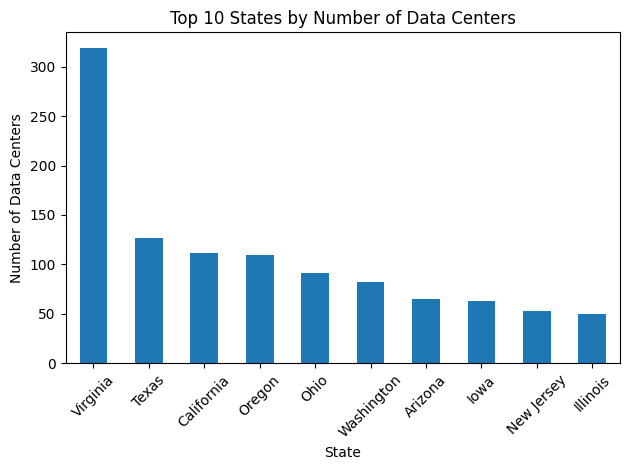

In [10]:
# Number of data centers per state (Top 10)
state_counts = gdf_data_centers['state'].value_counts().head(10)

state_counts.plot(kind='bar')
plt.title('Top 10 States by Number of Data Centers')
plt.xlabel('State')
plt.ylabel('Number of Data Centers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

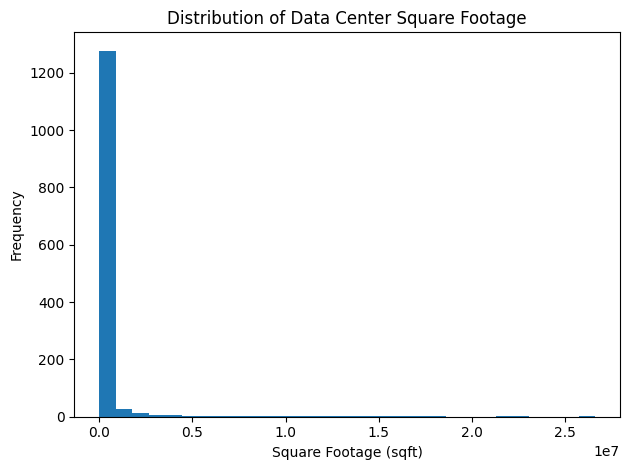

In [11]:
# Distribution of data center square footage
gdf_data_centers['sqft'].plot(kind='hist', bins=30)

plt.title('Distribution of Data Center Square Footage')
plt.xlabel('Square Footage (sqft)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

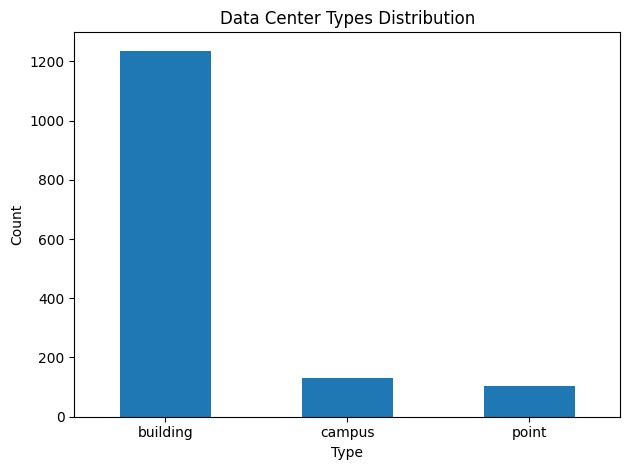

In [12]:
# Distribution of data center types
type_counts = gdf_data_centers['type'].value_counts()

type_counts.plot(kind='bar')
plt.title('Data Center Types Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

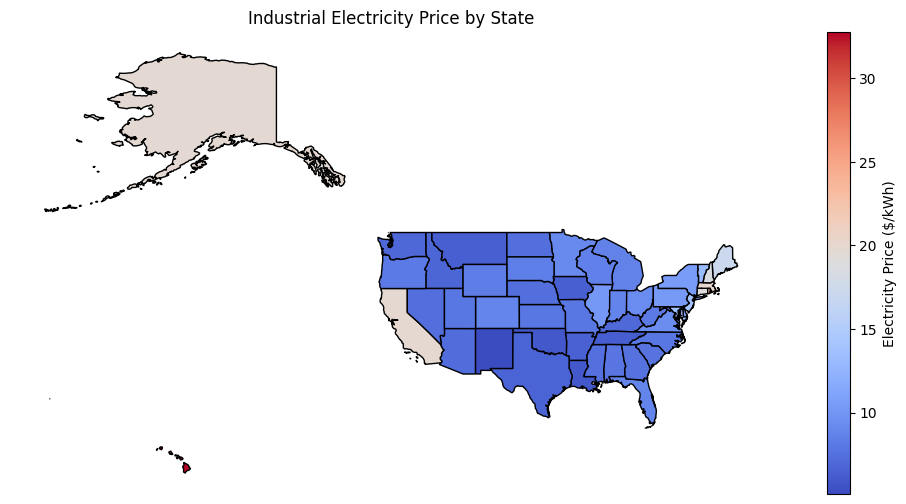

In [13]:
# Map of electricity prices by state
electricity_price_map = usa.merge(
    electricity_price_df,
    left_on='name',   
    right_on='state',
    how='left'
)

ax = electricity_price_map.plot(
    column='electricity_price',
    cmap='coolwarm',
    legend=True,
    edgecolor='black',
    missing_kwds={"color": "lightgrey"},
    legend_kwds={'label': "Electricity Price ($/kWh)"},
    figsize=(14, 6)
)

plt.title('Industrial Electricity Price by State')
plt.axis('off')
plt.show()

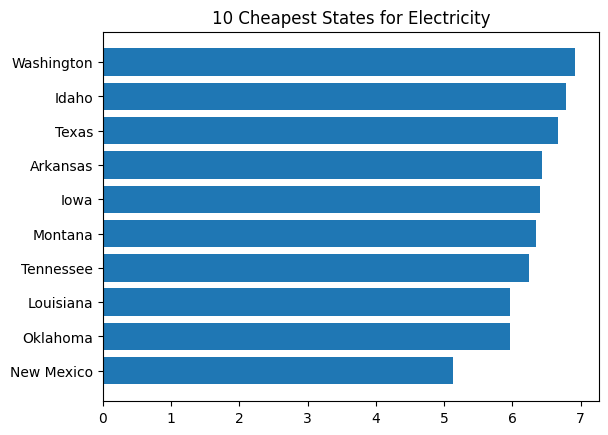

In [14]:
# Bar chart of the 10 cheapest states for electricity
sorted_prices = electricity_price_df.sort_values(by='electricity_price', ascending=True)
cheapest = sorted_prices.head(10)

plt.figure()
plt.barh(cheapest['state'], cheapest['electricity_price'])
plt.title('10 Cheapest States for Electricity')
plt.show()

Pearson’s r: 0.01565741628957343


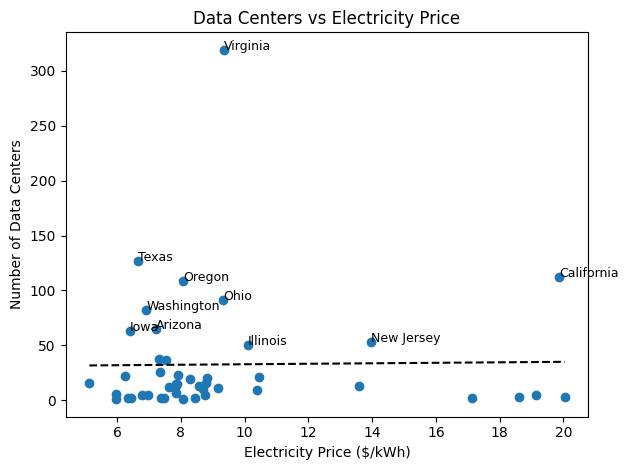

In [33]:
# Data Centers vs. Industrial Electricity Price
dc_counts = data_centers_df['state'].value_counts().reset_index()
dc_counts.columns = ['state', 'num_data_centers']

df_corr = dc_counts.merge(
    electricity_price_df[['state', 'electricity_price']],
    on='state',
    how='left'
)

correlation = df_corr['num_data_centers'].corr(df_corr['electricity_price'])
print(f"Pearson’s r: {correlation}")

df_clean = df_corr[['state', 'electricity_price', 'num_data_centers']].dropna()

x = df_clean['electricity_price']
y = df_clean['num_data_centers']


plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)
sorted_idx = np.argsort(x)
x_sorted = x.iloc[sorted_idx]
y_line = m * x_sorted + b

plt.plot(x_sorted, y_line, linestyle='--', color='black')

top_states = df_clean.nlargest(10, 'num_data_centers')

for _, row in top_states.iterrows():
    plt.text(
        row['electricity_price'],
        row['num_data_centers'],
        row['state'],
        fontsize=9
    )

plt.xlabel('Electricity Price ($/kWh)')
plt.ylabel('Number of Data Centers')
plt.title('Data Centers vs Electricity Price')

plt.tight_layout()
plt.show()

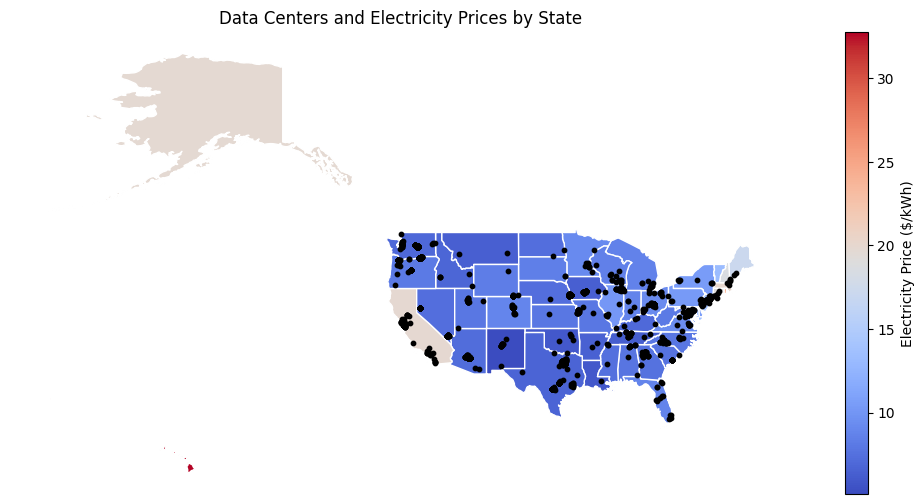

In [32]:
# Data Center Locations on Industrial Electricity Price by State
fig, ax = plt.subplots(figsize=(14, 6))

# Plot electricity price map
electricity_price_map.plot(
    column='electricity_price',
    cmap='coolwarm',
    legend=True,
    edgecolor='white',
    missing_kwds={"color": "lightgrey"},
    legend_kwds={'label': "Electricity Price ($/kWh)"},
    ax=ax
)

# Plot data centers on top
gdf_data_centers.plot(
    ax=ax,
    markersize=10,
    color='black'
)

ax.set_title('Data Centers and Electricity Prices by State')
ax.axis('off')

plt.show()